# BUSI Classification – ResNet50 vs Depthwise Separable CNN
**Classes: Benign (B) | Malignant (M) | Normal (N)**

Key additions over baseline:
- **Class weights** computed from training split and passed to `CrossEntropyLoss`
- **ResNet50** (pretrained, fine-tuned) replaces ResNet18
- **Depthwise Separable CNN** – lightweight custom architecture
- Side-by-side comparison: accuracy, F1, confusion matrices, training curves

## 1. Install & Import

In [1]:
import subprocess, sys
pkgs = [
    'numpy', 'matplotlib', 'Pillow',
    'scikit-learn', 'seaborn',
    'torch==2.4.1', 'torchvision==0.19.1',
    '--extra-index-url', 'https://download.pytorch.org/whl/cpu'
]
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + pkgs)
print('All packages ready.')

All packages ready.


In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset

import torchvision
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import classification_report, confusion_matrix

print(f'torch      : {torch.__version__}')
print(f'torchvision: {torchvision.__version__}')
print('Imports OK.')

torch      : 2.4.1+cpu
torchvision: 0.19.1+cpu
Imports OK.


## 2. Configuration

In [3]:
import os, subprocess

# Auto-detect BUSI dataset path
def find_busi_dataset():
    # 1. Check common relative paths first
    candidates = [
        'Dataset_BUSI_with_GT',
        '../Dataset_BUSI_with_GT',
        '../../Dataset_BUSI_with_GT',
        os.path.expanduser('~/Dataset_BUSI_with_GT'),
        os.path.expanduser('~/Desktop/Dataset_BUSI_with_GT'),
    ]
    for path in candidates:
        if os.path.isdir(os.path.join(path, 'benign')):
            return os.path.abspath(path)

    # 2. Search the home directory
    result = subprocess.run(
        ['find', os.path.expanduser('~'), '-type', 'd', '-name', 'benign', '-maxdepth', '8'],
        capture_output=True, text=True, timeout=15
    )
    for line in result.stdout.strip().splitlines():
        parent = os.path.dirname(line)
        if all(os.path.isdir(os.path.join(parent, c)) for c in ['benign', 'malignant', 'normal']):
            return parent

    return None

DATA_DIR = find_busi_dataset()
if DATA_DIR:
    print(f'✅ Dataset found at: {DATA_DIR}')
else:
    # Fallback: set manually
    DATA_DIR = '/path/to/Dataset_BUSI_with_GT'  # <-- change this if not found
    print('⚠️  Could not auto-detect. Please set DATA_DIR manually above.')

IMG_SIZE = 224
BATCH    = 32
EPOCHS   = 20
LR       = 1e-4
SEED     = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

CLASSES   = ['benign', 'malignant', 'normal']
CLASS_MAP = {c: i for i, c in enumerate(CLASSES)}
device    = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Config set. Device:', device)

✅ Dataset found at: /home/patan/Desktop/AAA_Game/DLMIP/Assignment2/Dataset_BUSI_with_GT
Config set. Device: cpu


## 3. Dataset

In [4]:
class BUSIDataset(Dataset):
    """BUSI dataset – skips mask files."""

    def __init__(self, root, transform=None):
        self.samples   = []
        self.transform = transform
        for label, cls in enumerate(CLASSES):
            folder = os.path.join(root, cls)
            for fname in sorted(os.listdir(folder)):
                if 'mask' in fname.lower():
                    continue
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append((os.path.join(folder, fname), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

In [5]:
# Transforms
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Build datasets
train_full = BUSIDataset(DATA_DIR, transform=train_tf)
val_full   = BUSIDataset(DATA_DIR, transform=val_tf)
test_full  = BUSIDataset(DATA_DIR, transform=val_tf)

n       = len(train_full)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

g       = torch.Generator().manual_seed(SEED)
indices = torch.randperm(n, generator=g).tolist()

train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train + n_val]
test_idx  = indices[n_train + n_val:]

train_ds = Subset(train_full, train_idx)
val_ds   = Subset(val_full,   val_idx)
test_ds  = Subset(test_full,  test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Train: 546 | Val: 117 | Test: 117


## 4. Class Weights

Class weights are computed from the **training split only** to avoid data leakage.

Formula: `w_c = N_total / (C * N_c)`  
where `N_total` = total training samples, `C` = number of classes, `N_c` = samples in class `c`.

Minority classes (malignant, normal) get **higher weights**, penalising the model more for misclassifying them.

In [6]:
# Collect labels from the training subset
train_labels = [train_full.samples[i][1] for i in train_idx]
label_counts  = Counter(train_labels)
n_train_total = len(train_labels)
n_classes     = len(CLASSES)

# w_c = N / (C * N_c)
class_weights = torch.tensor(
    [n_train_total / (n_classes * label_counts[c]) for c in range(n_classes)],
    dtype=torch.float
).to(device)

print('Class weights (Benign | Malignant | Normal):')
for cls, w in zip(CLASSES, class_weights.cpu()):
    print(f'  {cls:12s}: {w:.4f}  (n={label_counts[CLASSES.index(cls)]})')

criterion = nn.CrossEntropyLoss(weight=class_weights)
print('\nCrossEntropyLoss with class weights ready.')

Class weights (Benign | Malignant | Normal):
  benign      : 0.5852  (n=311)
  malignant   : 1.2297  (n=148)
  normal      : 2.0920  (n=87)

CrossEntropyLoss with class weights ready.


## 5. Model A – ResNet50 (Pretrained + Fine-tuned)

In [7]:
def build_resnet50():
    """Load pretrained ResNet50, replace final FC for 3-class output."""
    weights = ResNet50_Weights.IMAGENET1K_V1
    model   = resnet50(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model.to(device)

resnet_model = build_resnet50()
total_params = sum(p.numel() for p in resnet_model.parameters())
print(f'ResNet50 — Total params: {total_params:,}')

ResNet50 — Total params: 23,514,179


## 6. Model B – Depthwise Separable CNN

A depthwise separable convolution splits a standard conv into:
1. **Depthwise conv** – one filter per input channel (spatial features)
2. **Pointwise conv** – 1×1 conv to mix channels (cross-channel features)

This reduces parameters ~8–9× compared to a standard conv with similar capacity.

In [8]:
class DepthwiseSeparableBlock(nn.Module):
    """Depthwise separable conv block: DW conv → BN → ReLU → PW conv → BN → ReLU."""

    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel_size=3, stride=stride,
                            padding=1, groups=in_ch, bias=False)  # depthwise
        self.bn1 = nn.BatchNorm2d(in_ch)
        self.pw = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)  # pointwise
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.act(self.bn1(self.dw(x)))
        x = self.act(self.bn2(self.pw(x)))
        return x


class DepthwiseCNN(nn.Module):
    """
    Lightweight custom CNN using depthwise separable convolutions.
    Architecture:
      Stem conv  → 32 ch, stride 2
      DW block   → 64 ch, stride 2
      DW block   → 128 ch, stride 2
      DW block   → 256 ch, stride 2
      DW block   → 512 ch, stride 2
      Global Avg Pool → FC (512 → n_classes)
    Input 224×224 → ~7×7 feature map before pooling.
    """

    def __init__(self, num_classes=3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.blocks = nn.Sequential(
            DepthwiseSeparableBlock(32,  64,  stride=2),
            DepthwiseSeparableBlock(64,  128, stride=2),
            DepthwiseSeparableBlock(128, 256, stride=2),
            DepthwiseSeparableBlock(256, 512, stride=2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc   = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x)


dw_model    = DepthwiseCNN(num_classes=n_classes).to(device)
total_dw    = sum(p.numel() for p in dw_model.parameters())
print(f'Depthwise CNN — Total params: {total_dw:,}')

Depthwise CNN — Total params: 183,747


## 7. Shared Training Function

In [9]:
def train_model(model, train_loader, val_loader, criterion, lr=LR, epochs=EPOCHS, label='Model'):
    """Train and validate; return history dict."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        # --- train ---
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * imgs.size(0)
            correct  += (out.argmax(1) == labels).sum().item()
            total    += imgs.size(0)
        t_loss = run_loss / total
        t_acc  = correct / total

        # --- val ---
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out    = model(imgs)
                loss   = criterion(out, labels)
                v_loss    += loss.item() * imgs.size(0)
                v_correct += (out.argmax(1) == labels).sum().item()
                v_total   += imgs.size(0)
        v_loss /= v_total
        v_acc   = v_correct / v_total

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        scheduler.step()

        print(f'[{label}] Epoch {epoch:02d}/{epochs} | '
              f'Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f} | '
              f'Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}')

    return history

## 8. Train ResNet50

In [10]:
print('=' * 60)
print('Training ResNet50 with class weights')
print('=' * 60)
resnet_history = train_model(
    resnet_model, train_loader, val_loader, criterion,
    lr=LR, epochs=EPOCHS, label='ResNet50'
)

Training ResNet50 with class weights
[ResNet50] Epoch 01/20 | Train Loss: 0.8363  Acc: 0.5604 | Val Loss: 1.1620  Acc: 0.6496
[ResNet50] Epoch 02/20 | Train Loss: 0.4281  Acc: 0.8187 | Val Loss: 0.3393  Acc: 0.7863
[ResNet50] Epoch 03/20 | Train Loss: 0.2882  Acc: 0.8864 | Val Loss: 0.3231  Acc: 0.8718
[ResNet50] Epoch 04/20 | Train Loss: 0.2034  Acc: 0.9048 | Val Loss: 0.4210  Acc: 0.8376
[ResNet50] Epoch 05/20 | Train Loss: 0.2016  Acc: 0.9194 | Val Loss: 0.3571  Acc: 0.8462
[ResNet50] Epoch 06/20 | Train Loss: 0.2342  Acc: 0.9121 | Val Loss: 0.5393  Acc: 0.7692
[ResNet50] Epoch 07/20 | Train Loss: 0.1827  Acc: 0.9286 | Val Loss: 0.4561  Acc: 0.8718
[ResNet50] Epoch 08/20 | Train Loss: 0.1285  Acc: 0.9597 | Val Loss: 0.3839  Acc: 0.8547
[ResNet50] Epoch 09/20 | Train Loss: 0.1257  Acc: 0.9487 | Val Loss: 0.5172  Acc: 0.8462
[ResNet50] Epoch 10/20 | Train Loss: 0.0932  Acc: 0.9652 | Val Loss: 0.4682  Acc: 0.8547
[ResNet50] Epoch 11/20 | Train Loss: 0.0863  Acc: 0.9670 | Val Loss: 0.38

## 9. Train Depthwise CNN

In [11]:
print('=' * 60)
print('Training Depthwise CNN with class weights')
print('=' * 60)
dw_history = train_model(
    dw_model, train_loader, val_loader, criterion,
    lr=LR, epochs=EPOCHS, label='DW-CNN'
)

Training Depthwise CNN with class weights
[DW-CNN] Epoch 01/20 | Train Loss: 1.1054  Acc: 0.2546 | Val Loss: 1.1269  Acc: 0.1880
[DW-CNN] Epoch 02/20 | Train Loss: 1.0918  Acc: 0.3993 | Val Loss: 1.1754  Acc: 0.1880
[DW-CNN] Epoch 03/20 | Train Loss: 1.0526  Acc: 0.5220 | Val Loss: 1.1001  Acc: 0.3333
[DW-CNN] Epoch 04/20 | Train Loss: 1.0658  Acc: 0.5037 | Val Loss: 1.1087  Acc: 0.3504
[DW-CNN] Epoch 05/20 | Train Loss: 1.0658  Acc: 0.4780 | Val Loss: 1.0919  Acc: 0.3333
[DW-CNN] Epoch 06/20 | Train Loss: 1.0602  Acc: 0.5055 | Val Loss: 1.0756  Acc: 0.3590
[DW-CNN] Epoch 07/20 | Train Loss: 1.0531  Acc: 0.4835 | Val Loss: 1.0776  Acc: 0.3590
[DW-CNN] Epoch 08/20 | Train Loss: 1.0494  Acc: 0.4762 | Val Loss: 1.0829  Acc: 0.3504
[DW-CNN] Epoch 09/20 | Train Loss: 1.0387  Acc: 0.4963 | Val Loss: 1.0763  Acc: 0.3932
[DW-CNN] Epoch 10/20 | Train Loss: 1.0520  Acc: 0.4835 | Val Loss: 1.0787  Acc: 0.3590
[DW-CNN] Epoch 11/20 | Train Loss: 1.0434  Acc: 0.4853 | Val Loss: 1.0721  Acc: 0.3846
[

## 10. Training Curves – Side by Side

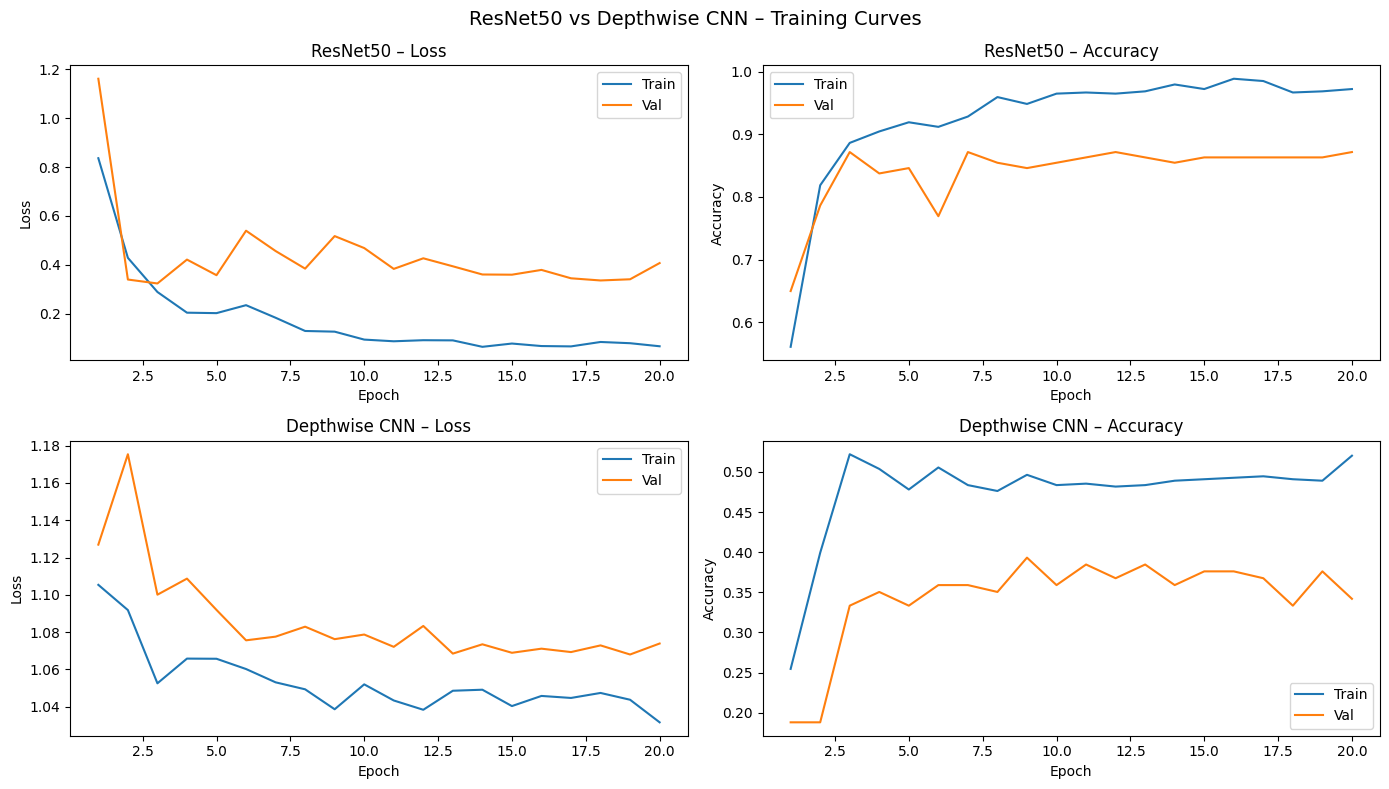

In [12]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('ResNet50 vs Depthwise CNN – Training Curves', fontsize=14)

# ResNet50 Loss
axes[0, 0].plot(epochs_range, resnet_history['train_loss'], label='Train')
axes[0, 0].plot(epochs_range, resnet_history['val_loss'],   label='Val')
axes[0, 0].set_title('ResNet50 – Loss')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# ResNet50 Accuracy
axes[0, 1].plot(epochs_range, resnet_history['train_acc'], label='Train')
axes[0, 1].plot(epochs_range, resnet_history['val_acc'],   label='Val')
axes[0, 1].set_title('ResNet50 – Accuracy')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

# DW-CNN Loss
axes[1, 0].plot(epochs_range, dw_history['train_loss'], label='Train')
axes[1, 0].plot(epochs_range, dw_history['val_loss'],   label='Val')
axes[1, 0].set_title('Depthwise CNN – Loss')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()

# DW-CNN Accuracy
axes[1, 1].plot(epochs_range, dw_history['train_acc'], label='Train')
axes[1, 1].plot(epochs_range, dw_history['val_acc'],   label='Val')
axes[1, 1].set_title('Depthwise CNN – Accuracy')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 11. Evaluation on Test Set

In [13]:
def evaluate(model, loader, label='Model'):
    """Run inference on test set; return preds and ground-truth labels."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs  = imgs.to(device)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    print(f'\n── {label} ──')
    print(classification_report(
        all_labels, all_preds,
        target_names=['Benign (B)', 'Malignant (M)', 'Normal (N)'],
        zero_division=0
    ))
    return all_preds, all_labels


resnet_preds, resnet_labels = evaluate(resnet_model, test_loader, 'ResNet50')
dw_preds,     dw_labels     = evaluate(dw_model,     test_loader, 'Depthwise CNN')


── ResNet50 ──
               precision    recall  f1-score   support

   Benign (B)       0.83      0.93      0.88        57
Malignant (M)       0.91      0.80      0.85        40
   Normal (N)       0.94      0.85      0.89        20

     accuracy                           0.87       117
    macro avg       0.90      0.86      0.87       117
 weighted avg       0.88      0.87      0.87       117


── Depthwise CNN ──
               precision    recall  f1-score   support

   Benign (B)       0.74      0.30      0.42        57
Malignant (M)       0.43      0.80      0.56        40
   Normal (N)       0.32      0.30      0.31        20

     accuracy                           0.47       117
    macro avg       0.49      0.47      0.43       117
 weighted avg       0.56      0.47      0.45       117



## 12. Confusion Matrices

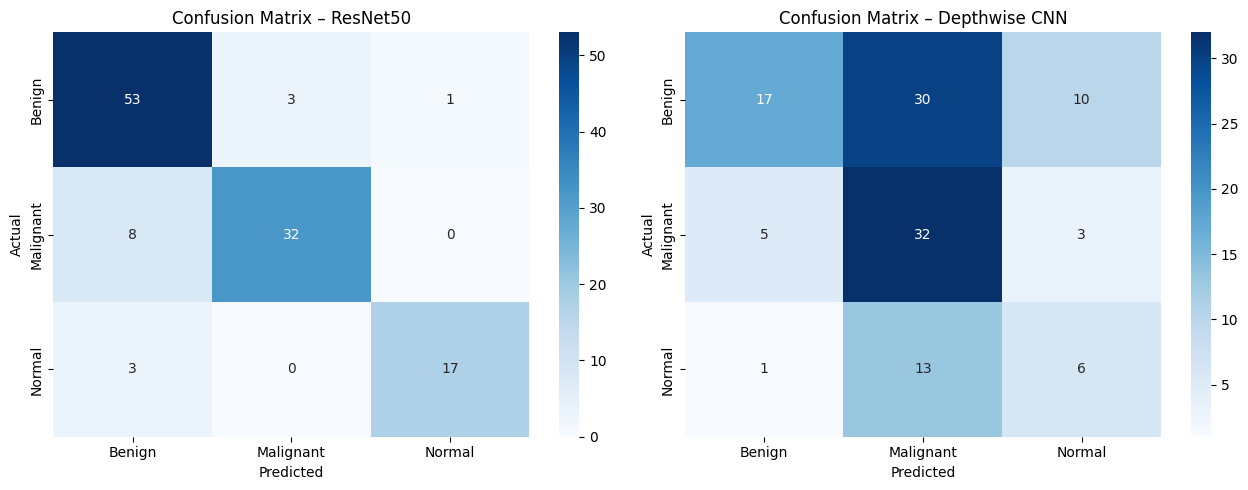

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
tick_labels = ['Benign', 'Malignant', 'Normal']

for ax, preds, labels, title in [
    (axes[0], resnet_preds, resnet_labels, 'ResNet50'),
    (axes[1], dw_preds,     dw_labels,     'Depthwise CNN'),
]:
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=tick_labels, yticklabels=tick_labels)
    ax.set_title(f'Confusion Matrix – {title}', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 13. Summary Comparison

In [15]:
from sklearn.metrics import accuracy_score, f1_score

def summary_stats(preds, labels):
    acc    = accuracy_score(labels, preds)
    f1_mac = f1_score(labels, preds, average='macro',    zero_division=0)
    f1_wt  = f1_score(labels, preds, average='weighted', zero_division=0)
    return acc, f1_mac, f1_wt

r_acc, r_f1m, r_f1w = summary_stats(resnet_preds, resnet_labels)
d_acc, d_f1m, d_f1w = summary_stats(dw_preds,     dw_labels)

r_params = sum(p.numel() for p in resnet_model.parameters())
d_params = sum(p.numel() for p in dw_model.parameters())

print(f'{"Metric":<22} {"ResNet50":>12} {"Depthwise CNN":>15}')
print('-' * 52)
print(f'{"Accuracy":<22} {r_acc:>12.4f} {d_acc:>15.4f}')
print(f'{"Macro F1":<22} {r_f1m:>12.4f} {d_f1m:>15.4f}')
print(f'{"Weighted F1":<22} {r_f1w:>12.4f} {d_f1w:>15.4f}')
print(f'{"Parameters":<22} {r_params:>12,} {d_params:>15,}')
print(f'{"Param ratio":<22} {"1.00x":>12} {d_params/r_params:>14.2f}x')

Metric                     ResNet50   Depthwise CNN
----------------------------------------------------
Accuracy                     0.8718          0.4701
Macro F1                     0.8747          0.4297
Weighted F1                  0.8715          0.4499
Parameters               23,514,179         183,747
Param ratio                   1.00x           0.01x


## 14. Save Models

In [16]:
torch.save(resnet_model.state_dict(), 'busi_resnet50_classweights.pth')
torch.save(dw_model.state_dict(),     'busi_depthwise_classweights.pth')
print('Models saved.')

Models saved.
